<div style="background:linear-gradient(135deg,#064e3b 0%,#047857 55%,#34d399 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a7f3d0;font-weight:700;text-transform:uppercase">Chapter 180 &middot; Capstone 20 &middot; Non-Probability Samples</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Repairing an Online Panel</div>
  <div style="font-size:15px;color:#d1fae5;max-width:820px;line-height:1.6">Five thousand two hundred people, matched to the census on age, sex and region. It is ten points wrong, standard weighting does not move it at all, and a probability sample one thirteenth the size beats it comfortably.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
EM, DK, LT, RD, MUT = "#047857", "#064e3b", "#34d399", "#dc2626", "#94a3b8"
AGE=["18-34","35-54","55+"]; SEX=["Female","Male"]; REG=["Northeast","Midwest","South","West"]
IU=["Low","Medium","High"]

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-repairing-an-online-panel.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw     = load("panel");            prob = load("probability_sample")
m_as    = load("census_age_sex");   m_r  = load("census_region")
m_iu    = load("official_internet_use")
truth   = load("truth");            plan = load("CollectionPlan")
N     = int(truth.loc[truth.quantity.str.contains("adults"),"value"].iloc[0])
TRUE  = float(truth.loc[truth.quantity.str.contains("true share"),"value"].iloc[0])
print("panel rows:", len(raw), "| probability sample:", len(prob))
raw.head()

panel rows: 5202 | probability sample: 420


,respondent_id,age_band,sex,region,internet_use,used_service
0,P70000,35-54,Male,South,Medium,0.0
1,P70001,55+,Female,West,Medium,1.0
2,P70002,35-54,Male,Northeast,Medium,1.0
3,P70003,35-54,Female,Northeast,Medium,0.0
4,P70004,55+,Female,South,High,0.0


## Step D1 to D4 &middot; A sample with no selection probabilities
The target population is 240,000 adults. There is no frame: panel members opted in through advertising and referrals, so **the probability that any given adult is in this sample is unknown and cannot be recovered**. That single sentence rules out every standard error in the book.

In [2]:
for line in plan.collection_plan:
    print(line)

D1 TARGET POPULATION: all 240,000 adults in the region.
D2 FRAME: there is no frame. Panel members opted in through advertising and referrals, so the
   selection probability of any given adult is UNKNOWN and cannot be recovered.
D3 METHOD: quota sampling. Recruitment continued until the panel matched population shares on age,
   sex and region. NOTE: matching margins is NOT random selection. Within every quota cell,
   who joined was decided by willingness, not by chance.
D4 SIZE: 5,200 completes, chosen because it was affordable, not because a precision target required it.
D5 INSTRUMENT: a single behavioral question, plus the three quota variables.
BENCHMARK: an independent probability sample of 420 adults was commissioned alongside, drawn from
   the electoral register with in-person follow-up. It is small, expensive, and unbiased.
ANALYSIS: rake the panel to census margins, then compare both estimates against the true value and
   report the EQUIVALENT RANDOM SAMPLE SIZE of each.


**Quota sampling is the industry's answer to having no frame.** Recruitment continues until the panel matches known population shares on a few demographics. It is fast, it is cheap, and the resulting file looks convincing.

Note what it does not do. Matching a margin is not random selection. Within every quota cell, **who joined was decided by willingness**, and willingness is not a coin flip.

## Step 1 &middot; Clean, then check the quotas were actually met

In [3]:
d = raw.drop_duplicates(subset=["respondent_id"]).dropna(subset=["used_service"]).copy()
d["region"] = d.region.str.strip().str.title()
d["used_service"] = d.used_service.astype(int)
print(f"panel: {len(raw)} rows -> {len(d)} usable\n")
for col, order in [("age_band",AGE), ("sex",SEX), ("region",REG)]:
    got = d[col].value_counts(normalize=True).reindex(order)
    if col == "region":
        want = (m_r.set_index("region").population/N).reindex(order)
    elif col == "sex":
        want = (m_as.groupby("sex").population.sum()/N).reindex(order)
    else:
        want = (m_as.groupby("age_band").population.sum()/N).reindex(order)
    print(f"{col}")
    for k in order:
        print(f"   {k:10s} panel {got[k]:.3f}   population {want[k]:.3f}   gap {got[k]-want[k]:+.3f}")

panel: 5202 rows -> 5197 usable

age_band
   18-34      panel 0.301   population 0.301   gap +0.000
   35-54      panel 0.349   population 0.350   gap -0.000
   55+        panel 0.349   population 0.349   gap +0.000
sex
   Female     panel 0.511   population 0.511   gap +0.000
   Male       panel 0.489   population 0.489   gap -0.000
region
   Northeast  panel 0.278   population 0.278   gap -0.000
   Midwest    panel 0.222   population 0.222   gap -0.000
   South      panel 0.349   population 0.349   gap +0.000
   West       panel 0.150   population 0.150   gap +0.000


**The quotas were met, to within a rounding error, on every one of them.** Age, sex and region all match the population. If a client asked whether the sample was representative, every check they know how to run would say yes.

## Step 2 &middot; First look

The quotas were met. That is worth seeing rather than reading, alongside the reason meeting them felt like enough.

In [4]:
print("HOW MUCH THE OUTCOME MOVES ACROSS EACH QUOTA VARIABLE")
for col, order in [("age_band", AGE), ("sex", SEX), ("region", REG)]:
    r = d.groupby(col).used_service.mean().reindex(order)
    print(f"  {col:10s} spans {(r.max()-r.min())*100:5.1f} points "
          f"({r.min():.1%} to {r.max():.1%})")
print("\nThe quota check in the previous step said all three match the population.")
print("The cell-by-cell figures are in the right-hand panel below.")

HOW MUCH THE OUTCOME MOVES ACROSS EACH QUOTA VARIABLE
  age_band   spans  27.7 points (30.8% to 58.5%)
  sex        spans   3.0 points (42.7% to 45.7%)
  region     spans   5.9 points (42.4% to 48.3%)

The quota check in the previous step said all three match the population.
The cell-by-cell figures are in the right-hand panel below.


**What this shows.** Only one of the three quota variables has much to do with the outcome. Age spans 28 percentage points, from 59 percent of under-35s down to 31 percent of the over-55s. Sex spans 3 points and region spans 6, which is close to nothing.

That is worth sitting with, because it makes the reassurance the quotas provide much thinner than it looks. Two of the three variables the panel was balanced on could not have biased this estimate whatever they had done, and the third is genuinely useful. Hitting all three still leaves the answer ten points out, so whatever selected these people is not in this table and is not strongly related to anything in it.

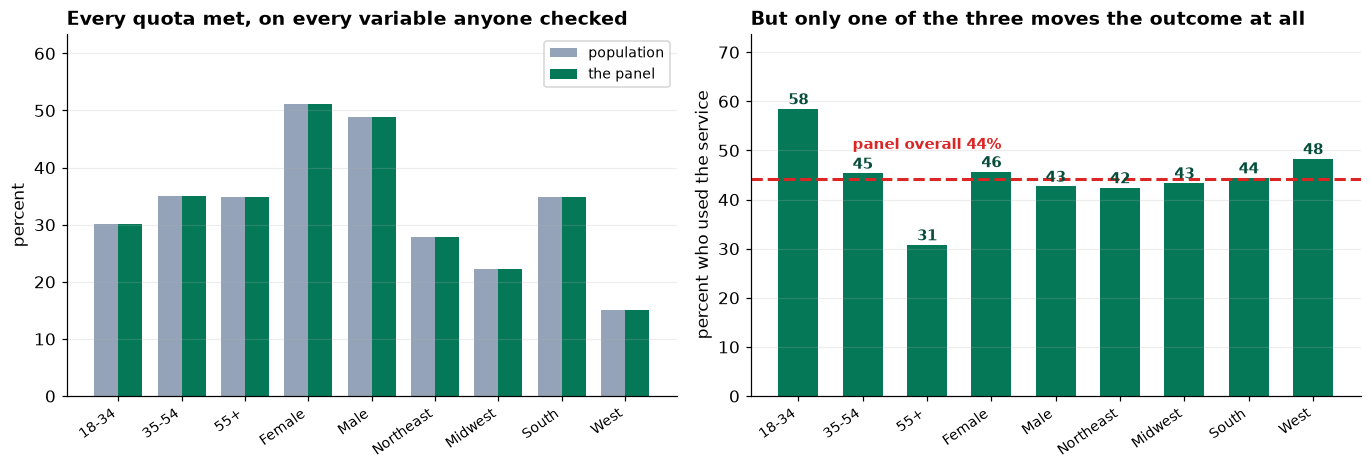

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
cells, got, want = [], [], []
for col, order in [("age_band", AGE), ("sex", SEX), ("region", REG)]:
    g = d[col].value_counts(normalize=True).reindex(order)
    if col == "region":
        w_ = (m_r.set_index("region").population/N).reindex(order)
    elif col == "sex":
        w_ = (m_as.groupby("sex").population.sum()/N).reindex(order)
    else:
        w_ = (m_as.groupby("age_band").population.sum()/N).reindex(order)
    for k in order:
        cells.append(k); got.append(g[k]*100); want.append(w_[k]*100)
xp, w = np.arange(len(cells)), 0.38
ax.bar(xp - w/2, want, width=w, color=MUT, label="population")
ax.bar(xp + w/2, got, width=w, color=EM, label="the panel")
ax.set_xticks(xp); ax.set_xticklabels(cells, fontsize=9, rotation=35, ha="right")
ax.set_ylim(0, max(max(got), max(want))*1.24)
ax.set_ylabel("percent")
ax.set_title("Every quota met, on every variable anyone checked")
ax.legend(fontsize=9, loc="upper right"); ax.grid(axis="x", alpha=0)

ax = axes[1]
rate = [d[d[c] == k].used_service.mean()*100
        for c, order in [("age_band", AGE), ("sex", SEX), ("region", REG)] for k in order]
ax.bar(xp, rate, color=EM, width=0.62)
for x, r_ in zip(xp, rate):
    ax.text(x, r_ + 0.9, f"{r_:.0f}", ha="center", fontsize=9.5, fontweight="bold", color=DK)
ax.axhline(d.used_service.mean()*100, color=RD, lw=2.0, ls="--")
ax.text(2, max(rate)*0.86, f"panel overall {d.used_service.mean():.0%}", color=RD,
        fontsize=9.5, fontweight="bold", ha="center")
ax.set_xticks(xp); ax.set_xticklabels(cells, fontsize=9, rotation=35, ha="right")
ax.set_ylim(0, max(rate)*1.26)
ax.set_ylabel("percent who used the service")
ax.set_title("But only one of the three moves the outcome at all")
ax.grid(axis="x", alpha=0)
plt.tight_layout(); plt.show()

**Left:** the pairs sit on top of each other. Any representativeness check a client knows how to run passes here. **Right:** the three age bars step down sharply and the other six are almost flat. Weighting on sex and region was never going to change this estimate, and weighting on age can only fix the part of the problem that age explains. Those two panels together are why quota sampling is persuasive, and why it fails quietly: a variable that is not on the left panel cannot be corrected for and never announces itself.

## Step 3 &middot; The estimate, against a probability sample and against the truth

In [6]:
p_panel = d.used_service.mean()
p_prob  = prob.used_service.mean()
se_prob = np.sqrt(p_prob*(1-p_prob)/len(prob))
print(f"opt-in panel        n = {len(d):5d}   estimate {p_panel:.4f}   error {p_panel-TRUE:+.4f}")
print(f"probability sample  n = {len(prob):5d}   estimate {p_prob:.4f}   error {p_prob-TRUE:+.4f}"
      f"   95% CI [{p_prob-1.96*se_prob:.4f}, {p_prob+1.96*se_prob:.4f}]")
print(f"\nTRUE population value            {TRUE:.4f}")
print(f"\nthe panel is {abs(p_panel-TRUE)/abs(p_prob-TRUE):.0f} times further from the truth,")
print(f"on {len(d)/len(prob):.0f} times the sample size.")

opt-in panel        n =  5197   estimate 0.4424   error +0.1015
probability sample  n =   420   estimate 0.3238   error -0.0171   95% CI [0.2791, 0.3686]

TRUE population value            0.3409

the panel is 6 times further from the truth,
on 12 times the sample size.


**Ten points wrong, on 5,197 people.** The probability sample of 420 is out by 1.7 points and its interval contains the truth. The panel's error is six times larger on twelve times the sample.

This is the whole argument for probability sampling in two lines, and it is why survey organizations still pay for expensive fieldwork when a panel costs a fraction as much.

## Step 4 &middot; Rake to the census margins, the standard repair

In [7]:
def rake(df, margins, iters=40):
    """Iterative proportional fitting.

    margins is a list of (columns, target share Series). Each pass nudges the weights
    so one margin matches, which knocks the others out; repeating converges on all.
    """
    w = np.ones(len(df))
    for _ in range(iters):
        for cols, target in margins:
            key = df[cols].astype(str).agg("|".join, axis=1)
            tgt = {"|".join(map(str, k if isinstance(k, tuple) else (k,))): v
                   for k, v in target.items()}
            cur = pd.Series(w).groupby(key.values).sum() / w.sum()
            w = w * key.map({k: tgt[k] / cur[k] for k in cur.index}).values
    return w / w.mean()

tgt_as = m_as.set_index(["age_band","sex"]).population/N
tgt_r  = m_r.set_index("region").population/N
w_demo = rake(d, [(["age_band","sex"], tgt_as), (["region"], tgt_r)])
p_demo = np.average(d.used_service, weights=w_demo)
print(f"raked to age x sex and region:  {p_demo:.4f}   error {p_demo-TRUE:+.4f}")
print(f"weight range {w_demo.min():.3f} to {w_demo.max():.3f}")
print(f"\nchange from the unweighted estimate: {p_demo-p_panel:+.5f}")

raked to age x sex and region:  0.4424   error +0.1015
weight range 0.999 to 1.002

change from the unweighted estimate: -0.00001


**Raking did nothing whatsoever.** Every weight came out at 1.000 and the estimate did not move.

That is not a bug. **Raking corrects a sample whose margins are wrong, and these margins were already right**, because the panel was recruited to make them right. There is nothing left for the procedure to adjust.

This is the trap in one line. The panel was built to pass exactly the check that the standard repair performs, so the repair certifies it and changes nothing, and the ten-point error survives untouched.

## Step 5 &middot; Find the variable that actually selected people
If demographics are not what makes this panel unusual, something else is. The panel questionnaire also carried a self-reported internet-use band, and an official communications survey publishes the same bands for the whole population.

In [8]:
cmp = pd.DataFrame({
    "panel": d.internet_use.value_counts(normalize=True).reindex(IU),
    "population": (m_iu.set_index("internet_use").population/N).reindex(IU)})
cmp["gap_pp"] = ((cmp.panel-cmp.population)*100).round(1)
print(cmp.round(3).to_string())
print("\nuse of the service, within each internet-use band:")
print(d.groupby("internet_use").used_service.agg(["size","mean"]).reindex(IU).round(3).to_string())

              panel  population  gap_pp
internet_use                           
Low           0.089       0.294   -20.5
Medium        0.459       0.443     1.6
High          0.453       0.263    19.0

use of the service, within each internet-use band:
              size   mean
internet_use             
Low            460  0.133
Medium        2385  0.322
High          2352  0.625


**There it is.** The panel is 45 percent heavy internet users against a population figure of 26, and it contains barely a third of the light users it should. That is who volunteers for an online panel, and it was invisible in every demographic check because **it cuts across age, sex and region rather than lining up with them**.

It also matters enormously for this particular question: heavy internet users are far likelier to have used an online government service. A variable that predicts both joining and the outcome is exactly the definition of the thing that biases an estimate.

## Step 6 &middot; Rake again, this time on the variable that matters

In [9]:
tgt_iu = m_iu.set_index("internet_use").population/N
w_full = rake(d, [(["age_band","sex"], tgt_as), (["region"], tgt_r), (["internet_use"], tgt_iu)])
p_full = np.average(d.used_service, weights=w_full)
n_eff  = w_full.sum()**2/(w_full**2).sum()
print(f"{'estimate':34s} {'value':>8s} {'error':>9s}")
print("-"*56)
for lab, est in [("panel, unweighted", p_panel), ("panel, raked on demographics", p_demo),
                 ("panel, raked + internet use", p_full), ("probability sample", p_prob)]:
    print(f"{lab:34s} {est:8.4f} {est-TRUE:+9.4f}")
print(f"{'TRUE value':34s} {TRUE:8.4f}")
print(f"\nrecovered {(1-abs(p_full-TRUE)/abs(p_panel-TRUE))*100:.0f}% of the bias")
print(f"weight range {w_full.min():.2f} to {w_full.max():.2f}  (ratio {w_full.max()/w_full.min():.0f}x)")
print(f"Kish effective n {n_eff:.0f} of {len(d)}  (design effect {len(d)/n_eff:.2f})")

estimate                              value     error
--------------------------------------------------------
panel, unweighted                    0.4424   +0.1015
panel, raked on demographics         0.4424   +0.1015
panel, raked + internet use          0.3559   +0.0150
probability sample                   0.3238   -0.0171
TRUE value                           0.3409

recovered 85% of the bias
weight range 0.25 to 8.29  (ratio 34x)
Kish effective n 2990 of 5197  (design effect 1.74)


**Eighty-five percent of the bias, gone.** Raking on the variable that actually drove selection takes the estimate from 44.2 percent to 35.6, against a true 34.1.

Two warnings come with it. The **weight range is 33 to 1**, far beyond the four-to-one seen in <a href="../chapters/capstone-stratified-customer-survey.html">Capstone 17</a>. A handful of light internet users are each standing in for dozens of people, and if those few happen to be unusual the correction inherits their oddity. And the effective sample size falls from 5,197 to about 3,000.

The deeper caution is that this worked **because someone thought to ask the right question and an official source published the matching margin**. Neither was guaranteed. The panel could just as easily have carried nothing but demographics, in which case the ten-point error would have been unfixable and, worse, undetectable.

## Step 7 &middot; What is this panel actually worth?
Sample size is the wrong currency for a biased sample. The useful question is: how large would a **random** sample have to be to be this far off?

In [10]:
print(f"{'sample':32s} {'n':>7s} {'error':>8s} {'equivalent random sample':>26s}")
print("-"*78)
for lab, est, nn in [("opt-in panel, unweighted", p_panel, len(d)),
                     ("opt-in panel, raked demographics", p_demo, len(d)),
                     ("opt-in panel, + internet use", p_full, len(d)),
                     ("probability sample", p_prob, len(prob))]:
    err = abs(est-TRUE)
    n_eq = TRUE*(1-TRUE)/err**2
    print(f"{lab:32s} {nn:7d} {err:8.4f} {n_eq:26,.0f}")
print("\nan SRS of size n has standard error sqrt(p(1-p)/n); setting that equal to the")
print("observed error gives the sample size that would have been equally accurate.")

sample                                 n    error   equivalent random sample
------------------------------------------------------------------------------
opt-in panel, unweighted            5197   0.1015                         22
opt-in panel, raked demographics    5197   0.1015                         22
opt-in panel, + internet use        5197   0.0150                      1,003
probability sample                   420   0.0171                        769

an SRS of size n has standard error sqrt(p(1-p)/n); setting that equal to the
observed error gives the sample size that would have been equally accurate.


**The 5,197-person panel is worth about twenty-two people.** That is not a rhetorical flourish, it is the arithmetic: a simple random sample of 22 adults would, on average, land as close to the truth as this panel did.

Raking on demographics leaves it at twenty-two, because it changed nothing. Raking on internet use lifts it to around a thousand, which is a genuine achievement and still means 80 percent of the fieldwork bought nothing.

And the probability sample of 420 is worth about 770, comfortably outperforming a panel more than twelve times its size.

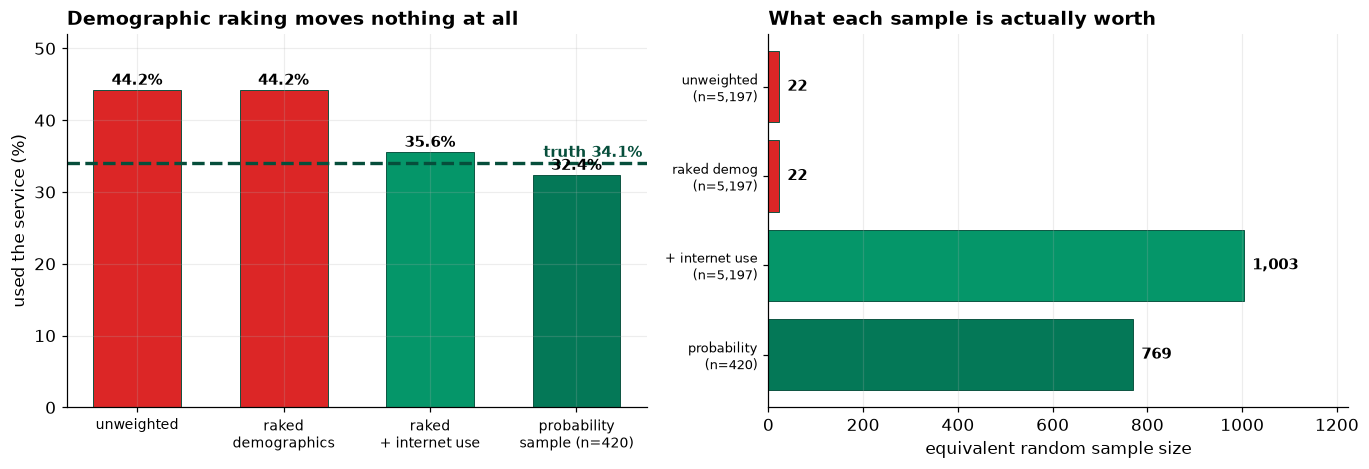

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
ax = axes[0]
labs = ["unweighted","raked\ndemographics","raked\n+ internet use","probability\nsample (n=420)"]
ests = [p_panel, p_demo, p_full, p_prob]
cols = [RD, RD, "#059669", EM]
ax.bar(range(4), [e*100 for e in ests], color=cols, edgecolor=DK, linewidth=0.6, width=0.6)
for i,e in enumerate(ests):
    ax.text(i, e*100+0.7, f"{e*100:.1f}%", ha="center", fontweight="bold", fontsize=10)
ax.axhline(TRUE*100, color=DK, lw=2.2, ls="--")
ax.text(3.45, TRUE*100+0.8, f"truth {TRUE*100:.1f}%", ha="right", fontsize=10, fontweight="bold", color=DK)
ax.set_xticks(range(4)); ax.set_xticklabels(labs, fontsize=9)
ax.set_ylabel("used the service (%)"); ax.set_ylim(0, 52)
ax.set_title("Demographic raking moves nothing at all")

ax = axes[1]
eq = [TRUE*(1-TRUE)/abs(e-TRUE)**2 for e in ests]
ax.barh(range(4), eq, color=cols, edgecolor=DK, linewidth=0.6)
for i,q in enumerate(eq):
    ax.text(q+18, i, f"{q:,.0f}", va="center", fontweight="bold", fontsize=10)
ax.set_yticks(range(4)); ax.set_yticklabels(["unweighted\n(n=5,197)","raked demog\n(n=5,197)",
                                             "+ internet use\n(n=5,197)","probability\n(n=420)"], fontsize=8.5)
ax.invert_yaxis(); ax.set_xlim(0, max(eq)*1.22)
ax.set_xlabel("equivalent random sample size")
ax.set_title("What each sample is actually worth"); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**Left:** four estimates against the truth. The first two bars are identical, which is the finding. **Right:** the same four expressed as the random sample each is equivalent to. The 420-person probability sample towers over the unweighted panel of five thousand.

## Step 8 &middot; Ethics, bias, and limits
- **A quota sample that matches the census is not representative, and it is marketed as though it were.** Every demographic check passes. That is a feature of the recruitment, not evidence about the estimate, and any report should say which checks were run and what they can and cannot establish.
- **Weight on what selected people, not on what is conventional.** Age, sex and region are weighted because they are always available, not because they are always the drivers. Here they were irrelevant, and the useful variable was one somebody had the foresight to ask about.
- **Publish the weight range.** A 33-to-1 spread means a few respondents are carrying whole segments of the population. That is a fragile estimate however good the central value looks, and a reader cannot judge it if the range is not shown.
- **The repair depended on luck.** An official source happened to publish internet-use bands. Without that margin the bias would have been not merely unfixable but invisible, and the panel would have reported 44 percent with total confidence.
- **Do not quote a margin of error for an opt-in panel without saying what it excludes.** The sampling error on 5,197 responses is about 1.4 points. The actual error was 10. Publishing the first number next to the second would be indefensible.
- **Bigger panels do not help.** Doubling the panel to 10,000 would halve the sampling error, which was never the problem, and leave the ten-point bias exactly where it was.

---
**From analysis to report.** The notebook carries the chain: the quota check that passes, the ten-point error, the raking that moves nothing, the auxiliary variable that reveals why, the second raking that recovers most of it, the weight range and effective sample size, and the equivalent-random-sample arithmetic that prices the whole exercise. The written reports turn it into guidance a research buyer can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.